# Decode TQEC-generated circuits with qLDPC

[TQEC](https://github.com/tqec/tqec) compiles lattice-surgery block graphs into Stim circuits.
This notebook starts from TQEC's logical-CNOT block graph, identifies correlation surfaces that define its logical observables, and compiles noisy circuits at several code distances.
It then compares qLDPC decoders that process either the complete detector history or overlapping time windows.

The `tqec` package is an external dependency used by this example; it is not part of qLDPC's installed API.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.
The install cell includes the external `tqec` package required by this example.


In [1]:
%%capture
%pip install qldpc matplotlib "tqec @ git+https://github.com/tqec/tqec.git"

In [2]:
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter
import tqec
import tqec.gallery
from matplotlib_inline.backend_inline import set_matplotlib_formats
from tqec.simulation.plotting.inset import plot_observable_as_inset
from tqec.simulation.simulation import start_simulation_using_sinter

from qldpc import circuits, decoders

set_matplotlib_formats("png")

## Simulation and plotting helpers

`get_simulation_data` compiles and samples the block graph at each requested code distance.
`plot_stats` gives each logical observable its own figure instead of combining distinct CNOT failure mechanisms into one curve.


In [3]:
def get_simulation_data(
    block_graph: tqec.BlockGraph,
    distances: Sequence[int],
    sinter_decoders: sinter.Decoder | Sequence[sinter.Decoder],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
) -> list[list[list[sinter.TaskStats]]]:
    """Simulate the given block graph at each code distance using start_simulation_using_sinter.

    Args:
        block_graph: The TQEC block graph describing the logical operation to simulate.
        distances: The surface code distances to simulate.
        sinter_decoders: A single decoder to use at all distances, or one decoder per distance.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stop sampling after this many errors have been seen.

    Returns:
        A list (over distances) of lists (over observables) of lists (over physical error rates)
            of sinter.TaskStats.
    """
    if isinstance(sinter_decoders, sinter.Decoder):
        custom_decoders = {str(dist): sinter_decoders for dist in distances}
    else:
        assert len(distances) == len(sinter_decoders)
        custom_decoders = {str(dist): decoder for dist, decoder in zip(distances, sinter_decoders)}
    correlation_surfaces = block_graph.find_correlation_surfaces()
    return [
        start_simulation_using_sinter(
            block_graph,
            [dist // 2],  # the "size" parameter for surface code patches in tqec
            error_rates,
            circuits.DepolarizingNoiseModel,
            manhattan_radius=2,
            observables=correlation_surfaces,
            max_shots=max_shots,
            max_errors=max_errors,
            decoders=[str(dist)],
            custom_decoders=custom_decoders,
            print_progress=False,
        )
        for dist in distances
    ]


def plot_stats(block_graph: tqec.BlockGraph, stats: list[list[list[sinter.TaskStats]]]) -> None:
    """Plot the logical error rate of each observable, with results grouped by code distance."""
    zx_graph = block_graph.to_zx_graph()
    correlation_surfaces = block_graph.find_correlation_surfaces()
    for observable, stat in zip(correlation_surfaces, zip(*stats)):
        _, ax = plt.subplots(figsize=(5, 4))
        sinter.plot_error_rate(
            ax=ax,
            stats=sum(stat, []),
            x_func=lambda s: s.json_metadata["p"],
            group_func=lambda s: s.json_metadata["d"],
        )
        plot_observable_as_inset(ax, zx_graph, observable)
        ax.grid(axis="both")
        ax.loglog()
        ax.set_xlabel("physical error rate")
        ax.set_ylabel("logical error rate")
        ax.legend(loc="best")
        ax.set_title("Logical CNOT observable")
        ax.figure.tight_layout()

## A logical CNOT and its observables

TQEC's gallery supplies the logical-CNOT block graph used throughout the notebook.
`find_correlation_surfaces` finds a generating set of surfaces whose measurement parities become Stim logical observables.
The interactive views below show the block graph and one such surface.


In [4]:
block_graph = tqec.gallery.cnot(tqec.Basis.Z)
block_graph.view_as_html()

In [5]:
correlation_surfaces = block_graph.find_correlation_surfaces()
block_graph.view_as_html(
    pop_faces_at_directions=("-Y",),
    show_correlation_surface=correlation_surfaces[0],
)

## Monolithic MWPM

The monolithic decoder sees the complete detector graph for each compiled circuit before making a prediction.
`decompose_errors=True` replaces a suggested correlated non-graphlike mechanism with graphlike components so MWPM can consume it.
That is an approximation to the original correlated model, not an exact treatment of every Y-type mechanism.


In [6]:
distances = [3, 5, 7]
decoder = decoders.SinterDecoder(
    with_MWPM=True,
    decompose_errors=True,  # decomposes non-graphlike Y errors into independent X and Z errors
)
mwpm_stats = get_simulation_data(block_graph, distances, decoder)

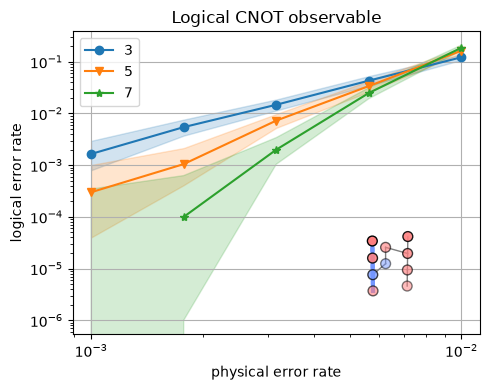

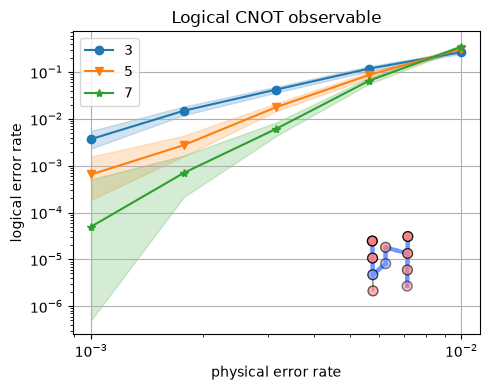

In [7]:
plot_stats(block_graph, mwpm_stats)
plt.show()

The two figures report distinct CNOT observables, and each point estimates the probability that its observable is decoded incorrectly in one compiled circuit execution.
Compare the finite-sample intervals at equal code distance and physical error rate; the lines between the five sampled rates are only visual guides.


## Sliding-window decoding

For a long computation, storing and decoding the complete detector history at once can become impractical.
The sliding-window decoder instead commits corrections a few rounds at a time while retaining overlapping history for the next window.
Here each window spans a number of rounds equal to the target code distance and advances by `distance // 2` rounds.


In [8]:
distances = [3, 5, 7]
sliding_window_decoders = [
    decoders.SlidingWindowDecoder(
        dist,  # decoding window size
        dist // 2,  # commit window size
        with_MWPM=True,
        decompose_errors=True,  # decomposes non-graphlike Y errors into independent X and Z errors
    )
    for dist in distances
]
sliding_window_stats = get_simulation_data(block_graph, distances, sliding_window_decoders)

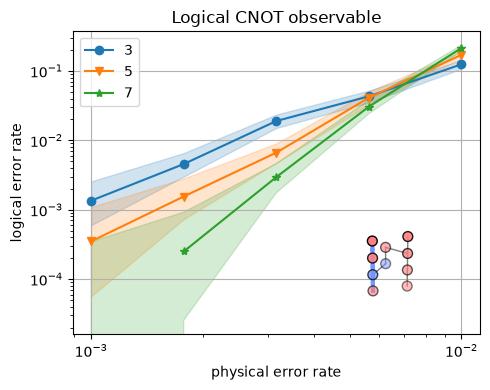

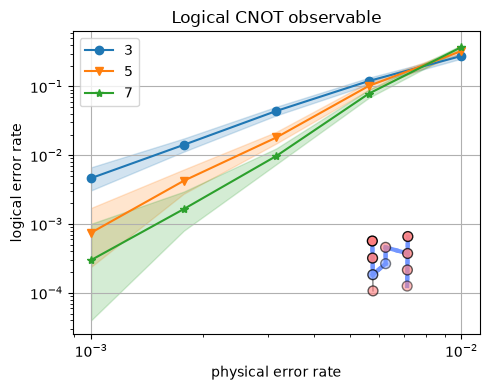

In [9]:
plot_stats(block_graph, sliding_window_stats)
plt.show()

This bounded comparison demonstrates how to connect TQEC circuits to the decoder interface; it is not a performance claim about either strategy.
Window size, stride, detector-time coordinates, the graphlike approximation, and the sample budget all affect the comparison.
